## Análisis de datos - Clase 3
---

## Taller práctico parte 1 - análisis inicial de un dataset
---


Vamos a realizar una actividad con un dataset con datos del Servicio Meteorológico Nacional Argentino. El dataset contiene estadísticas climáticas normales (período 1991-2020).

Fuente: https://www.smn.gob.ar/descarga-de-datos

Consigna: identificar los valores faltantes y posibles causas.

Resumen de variables:
* estación, provincia, latitud, longitud, altitud, número y NroOACI (estos dos últimos identifican las estaciones)
* mes
* temperatura media, máxima y mínima
* humedad relativa
* velocidad del viento
* nubosidad total (en meteorología, la nubosidad se mide en octas (0, despejado - 8 completamente cubierto), que representan la fracción del cielo cubierta por nubes)
* precipitación
* frecuencia de días con precipitación superior a 0,1 mm.

In [17]:
import pandas as pd
import numpy as np
from datetime import timedelta
import missingno as msno
import matplotlib.pyplot as plt
import seaborn as sns

In [18]:
smn_historico = pd.read_csv('../datasets/smn/smn_historico.csv', na_values=['S/D'])

In [19]:
smn_historico.head()

,estacion,provincia,altura,numero,NroOACI,LAT_decimal,LON_decimal,mes_txt,prec_sup_1mm,humedad,nubosidad,prec_mm,temp,temp_max,temp_min,viento
0,AEROPARQUE AERO,CAPITAL FEDERAL,6.0,87582.0,SABE,-34.55,-58.416667,Ene,6.7,67.0,3.1,117.5,24.5,28.4,20.8,16.8
1,AEROPARQUE AERO,CAPITAL FEDERAL,6.0,87582.0,SABE,-34.55,-58.416667,Feb,6.0,69.8,3.2,112.3,23.7,27.3,20.2,15.8
2,AEROPARQUE AERO,CAPITAL FEDERAL,6.0,87582.0,SABE,-34.55,-58.416667,Mar,5.9,71.3,3.1,111.8,22.0,25.5,18.8,14.9
3,AEROPARQUE AERO,CAPITAL FEDERAL,6.0,87582.0,SABE,-34.55,-58.416667,Abr,6.6,73.6,3.5,108.3,18.5,22.0,15.3,13.9
4,AEROPARQUE AERO,CAPITAL FEDERAL,6.0,87582.0,SABE,-34.55,-58.416667,May,5.0,76.4,4.0,83.3,15.2,18.4,12.3,12.9


In [54]:
rows, cols = smn_historico.shape

In [21]:
smn_historico.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1176 entries, 0 to 1175
Data columns (total 16 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   estacion      1176 non-null   object 
 1   provincia     1152 non-null   object 
 2   altura        1152 non-null   float64
 3   numero        1152 non-null   float64
 4   NroOACI       1140 non-null   object 
 5   LAT_decimal   1152 non-null   float64
 6   LON_decimal   1152 non-null   float64
 7   mes_txt       1176 non-null   object 
 8   prec_sup_1mm  1061 non-null   float64
 9   humedad       1110 non-null   float64
 10  nubosidad     1166 non-null   float64
 11  prec_mm       1061 non-null   float64
 12  temp          1167 non-null   float64
 13  temp_max      1158 non-null   float64
 14  temp_min      1124 non-null   float64
 15  viento        708 non-null    float64
dtypes: float64(12), object(4)
memory usage: 147.1+ KB


<Axes: >

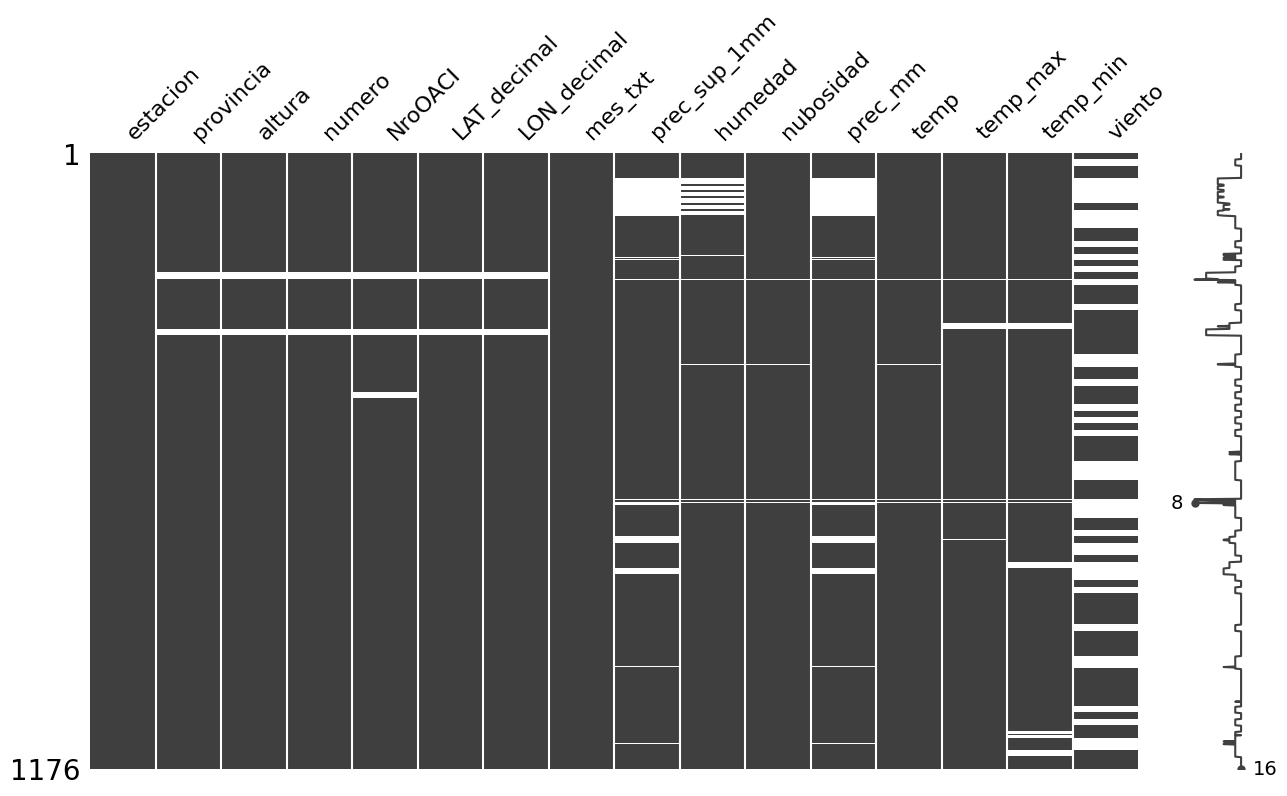

In [22]:
msno.matrix(smn_historico, figsize=(15,8))

<Axes: >

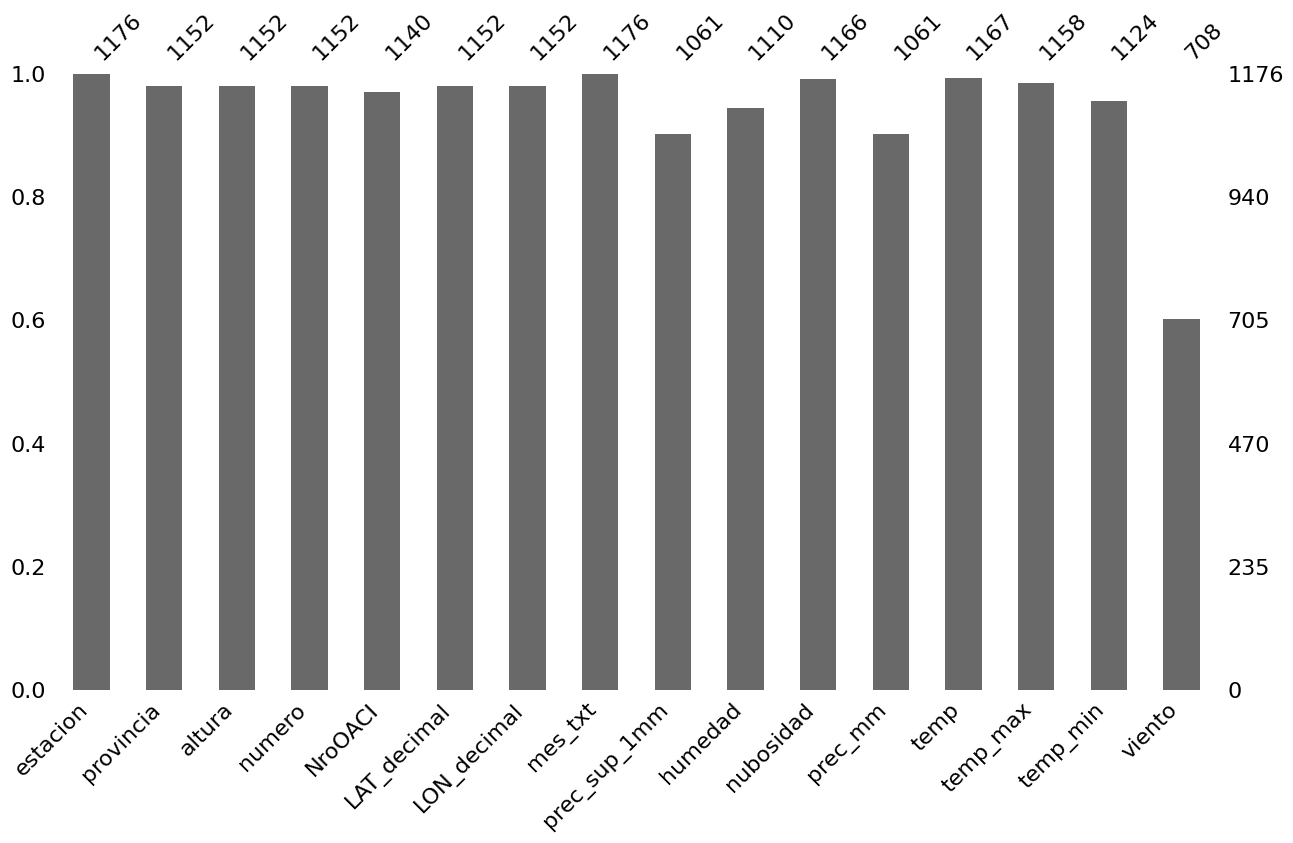

In [23]:
msno.bar(smn_historico, figsize=(15,8))


<Axes: >

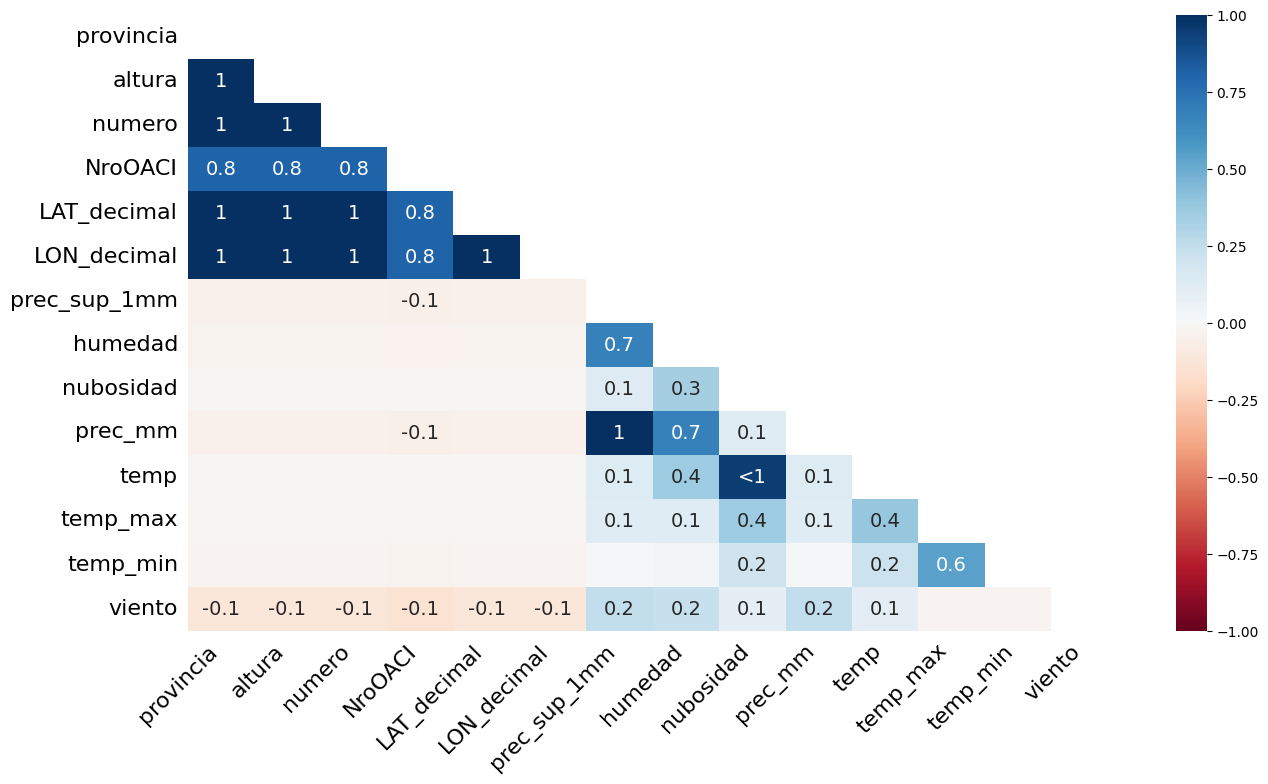

In [24]:
msno.heatmap(smn_historico, figsize=(15,8))

In [ ]:
# pd.set_option('display.max_rows', None)
# pd.set_option('display.max_columns', None)
# pd.set_option('display.max_colwidth', None)
# pd.set_option('display.width', None) 
# pd.reset_option('all')
df_prov = smn_historico.groupby(["numero","NroOACI"])
df_prov.head()

,estacion,provincia,altura,numero,NroOACI,LAT_decimal,LON_decimal,mes_txt,prec_sup_1mm,humedad,nubosidad,prec_mm,temp,temp_max,temp_min,viento
0,AEROPARQUE AERO,CAPITAL FEDERAL,6.0,87582.0,SABE,-34.550000,-58.416667,Ene,6.7,67.0,3.1,117.5,24.5,28.4,20.8,16.8
1,AEROPARQUE AERO,CAPITAL FEDERAL,6.0,87582.0,SABE,-34.550000,-58.416667,Feb,6.0,69.8,3.2,112.3,23.7,27.3,20.2,15.8
2,AEROPARQUE AERO,CAPITAL FEDERAL,6.0,87582.0,SABE,-34.550000,-58.416667,Mar,5.9,71.3,3.1,111.8,22.0,25.5,18.8,14.9
3,AEROPARQUE AERO,CAPITAL FEDERAL,6.0,87582.0,SABE,-34.550000,-58.416667,Abr,6.6,73.6,3.5,108.3,18.5,22.0,15.3,13.9
4,AEROPARQUE AERO,CAPITAL FEDERAL,6.0,87582.0,SABE,-34.550000,-58.416667,May,5.0,76.4,4.0,83.3,15.2,18.4,12.3,12.9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1164,VILLA REYNOLDS AERO,SAN LUIS,486.0,87448.0,SAOR,-33.716667,-65.366667,Ene,8.4,66.9,3.6,102.8,23.3,31.2,15.5,12.7
1165,VILLA REYNOLDS AERO,SAN LUIS,486.0,87448.0,SAOR,-33.716667,-65.366667,Feb,7.7,72.1,3.6,89.8,21.6,29.8,14.3,11.0
1166,VILLA REYNOLDS AERO,SAN LUIS,486.0,87448.0,SAOR,-33.716667,-65.366667,Mar,7.5,75.1,3.4,96.2,19.5,28.0,12.6,9.2
1167,VILLA REYNOLDS AERO,SAN LUIS,486.0,87448.0,SAOR,-33.716667,-65.366667,Abr,5.7,75.9,3.7,68.9,15.3,24.0,8.7,9.2


<Axes: >

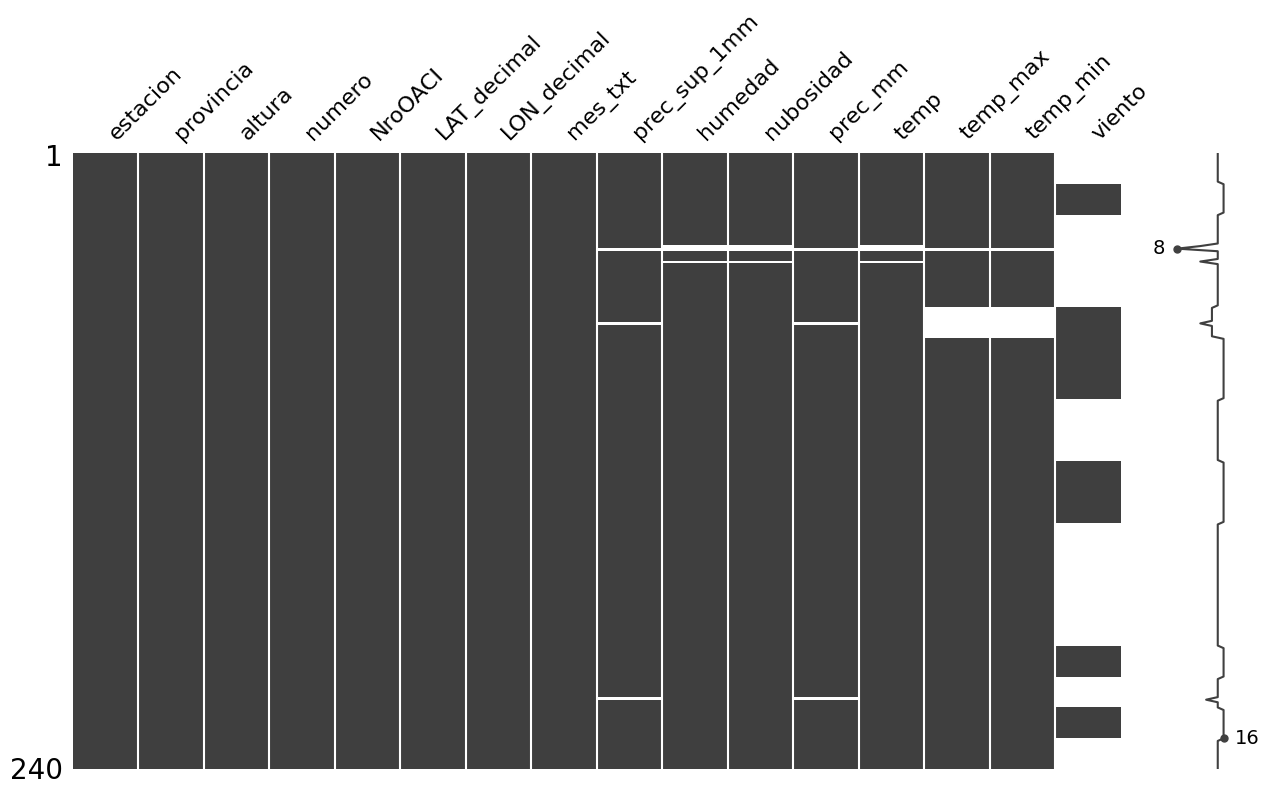

In [51]:
df_san_luis = smn_historico[smn_historico["provincia"] == "BUENOS AIRES"]
msno.matrix(df_san_luis, figsize=(15,8))

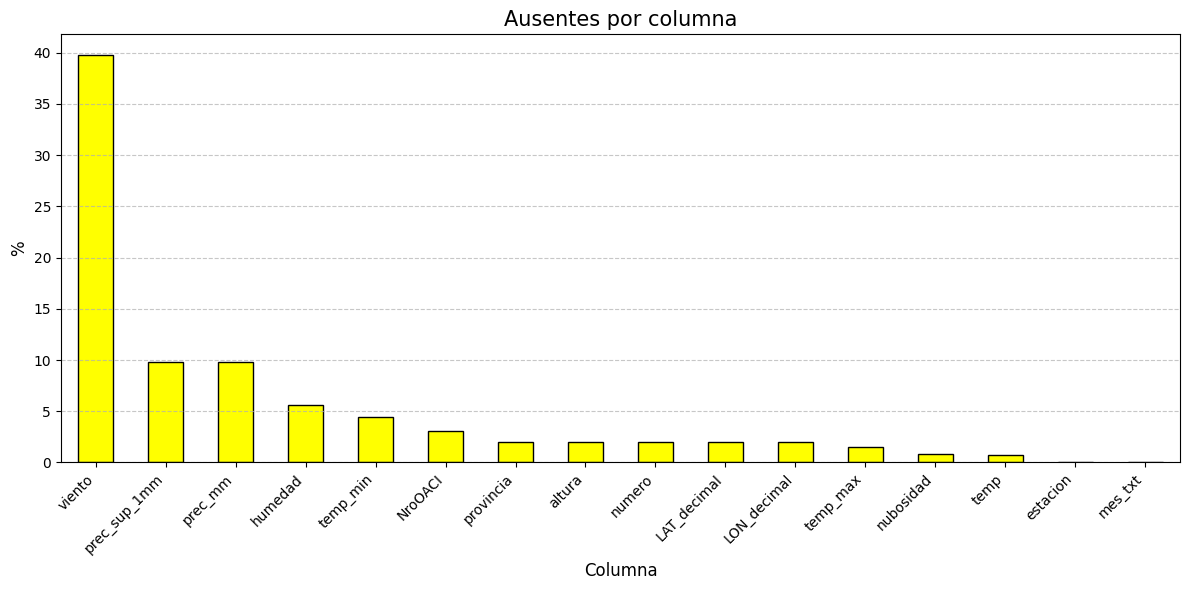

In [ ]:
df_missing_perc = (smn_historico.isna().sum()  / rows) * 100 
df_missing_perc_sorted = df_missing_perc.sort_values(ascending=False)

df_missing_perc_sorted.plot(kind='bar', figsize=(12, 6), color='yellow', edgecolor='black')

plt.title('Ausentes por columna', fontsize=15)
plt.ylabel('%', fontsize=12)
plt.xlabel('Columna', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


Text(0.5, 1.0, 'Matriz de Ausentes')

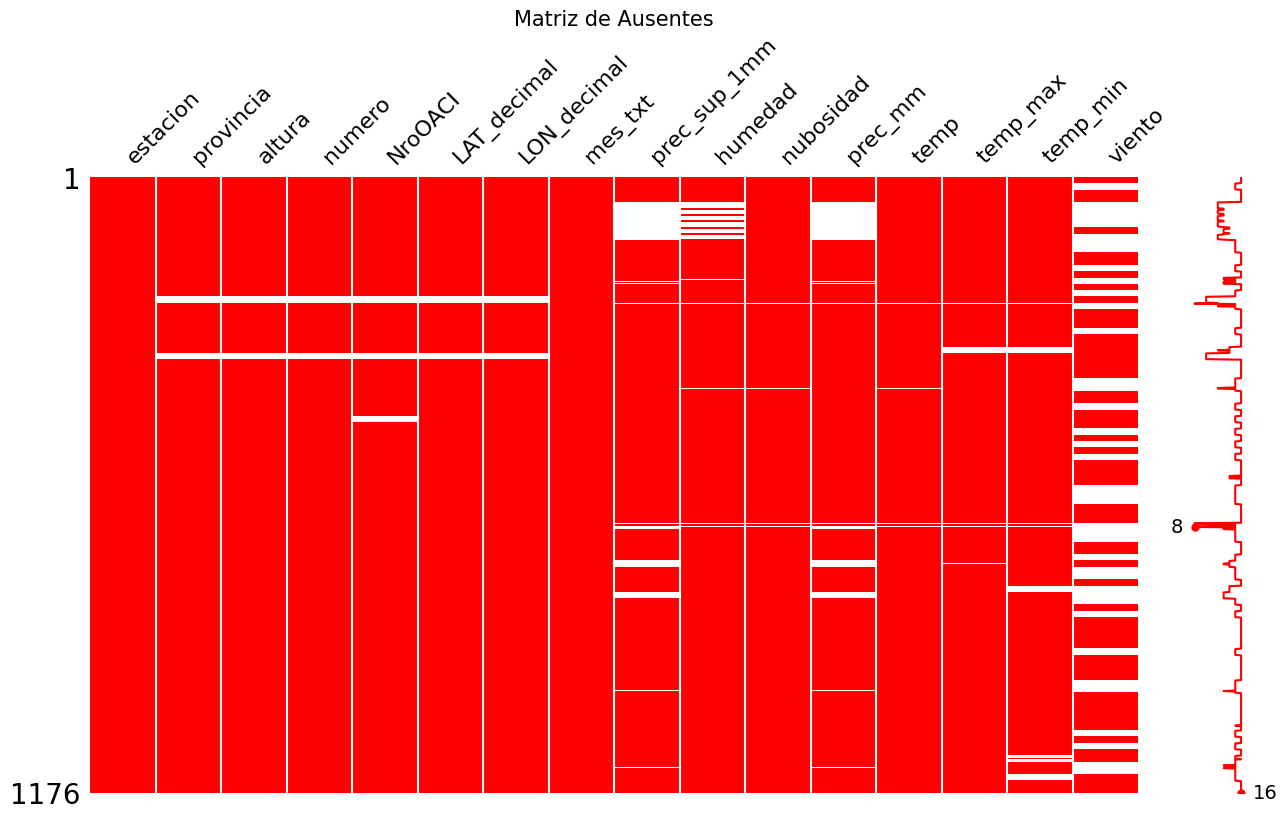

In [82]:
msno.matrix(smn_historico, figsize=(15,8),color=(1,0,0))
plt.title("Matriz de Ausentes",fontsize=15)

<Axes: >

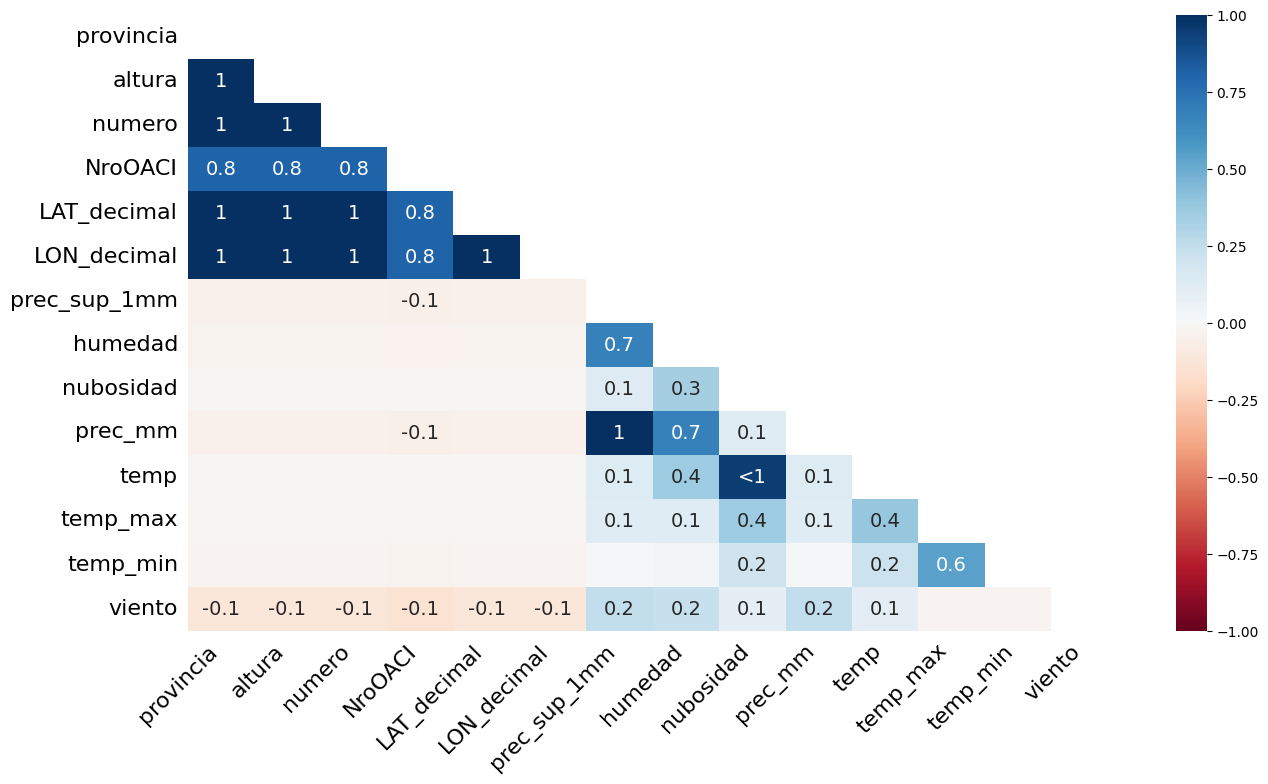

In [81]:
msno.heatmap(smn_historico, figsize=(15,8))


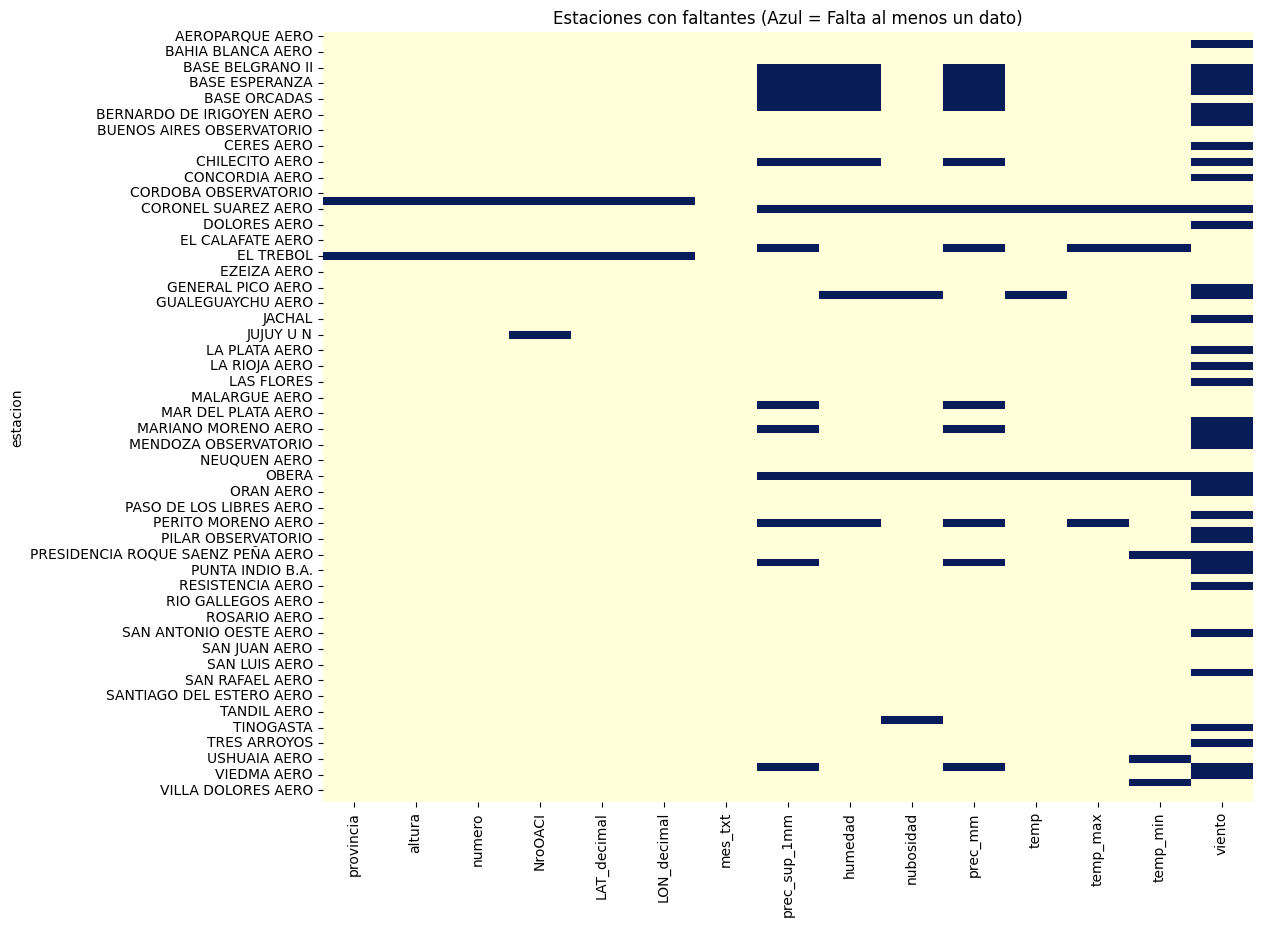

In [85]:
# 1. Agrupamos por el nombre de la estación (o ID)
# 2. Aplicamos una función lambda que devuelve True si hay algún nulo
df_diagnostico = smn_historico.groupby("estacion").agg(
    lambda x: x.isnull().any()
)

# 3. Opcional: Limpiar el DF (quitar columnas que no te interesen para el diagnóstico)
# Por ejemplo, las columnas de 'mes' o 'id' probablemente no tengan nulos.


# 4. Ver el resultado
plt.figure(figsize=(12, 10))
sns.heatmap(df_diagnostico, cmap="YlGnBu", cbar=False)
plt.title("Estaciones con faltantes (Azul = Falta al menos un dato)")
plt.show()

In [90]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', None) 
# pd.reset_option('all')
df_conteo_nulos = smn_historico.groupby("estacion").apply(lambda x: x.isnull().sum())
df_conteo_nulos


,estacion,provincia,altura,numero,NroOACI,LAT_decimal,LON_decimal,mes_txt,prec_sup_1mm,humedad,nubosidad,prec_mm,temp,temp_max,temp_min,viento
estacion,,,,,,,,,,,,,,,,
AEROPARQUE AERO,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
AZUL AERO,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,12
BAHIA BLANCA AERO,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
BARILOCHE AERO,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
BASE BELGRANO II,0,0,0,0,0,0,0,0,12,12,0,12,0,0,0,12
BASE CARLINI (EX JUBANY),0,0,0,0,0,0,0,0,12,7,0,12,0,0,0,12
BASE ESPERANZA,0,0,0,0,0,0,0,0,12,9,0,12,0,0,0,12
BASE MARAMBIO,0,0,0,0,0,0,0,0,12,10,0,12,0,0,0,12
BASE ORCADAS,0,0,0,0,0,0,0,0,12,8,0,12,0,0,0,0
